In this challenge, there is a connected undirected graph where each of the nodes is a color. Given a color, find the shortest path connecting any two nodes of that color. Each edge has a weight of . If there is not a pair or if the color is not found, print .

For example, given , and  edges  and  and colors for each node are  we can draw the following graph:

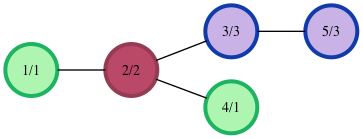

Each of the nodes is labeled [node]/[color] and is colored appropriately. If we want the shortest path between color , blue, we see there is a direct path between nodes  and . For green, color , we see the path length  from . There is no pair for node  having color , red.

Function Description

Complete the findShortest function in the editor below. It should return an integer representing the length of the shortest path between two nodes of the same color, or  if it is not possible.

findShortest has the following parameter(s):

g_nodes: an integer, the number of nodes
g_from: an array of integers, the start nodes for each edge
g_to: an array of integers, the end nodes for each edge
ids: an array of integers, the color id per node
val: an integer, the id of the color to match
Input Format

The first line contains two space-separated integers  and , the number of nodes and edges in the graph.
Each of the next  lines contains two space-separated integers  and , the nodes connected by an edge.
The next line contains  space-seperated integers, , representing the color id of each node from  to .
The last line contains the id of the color to analyze.

In [ ]:
#!/bin/python3

import math
import os
import random
import re
import sys
import heapq
# Complete the findShortest function below.

#
# For the weighted graph, <name>:
#
# 1. The number of nodes is <name>_nodes.
# 2. The number of edges is <name>_edges.
# 3. An edge exists between <name>_from[i] to <name>_to[i].
#
#
from typing import List
from collections import deque


WEIGHT = 1

"""

#Spec

We need to find the shortest path between any two nodes of the same color.

## Functional Requirements

@param graph_nodes, number of nodes
@param graph_from, list of source nodes
@param graph_to, list of destination nodes
@param ids, list of the node's color id value
@param val: is an entry related to the target id from where we will start the search for the color
@returns the shortest distance between two nodes of the same color in the graph

## Edge Cases

Since it's an undirected graph, if origin -> destination <=> destination -> origin
The colors are numbered starting from '1'. The colors are simply a value whose id ranges from 1 to graph_nodes + 1. If there are fewer than 2 nodes, we return -1 initially.
The shortest distance is 1 when two nodes of the same color are direct neighbors; if it reaches 1, there is no distance of 0 except for themselves.
Disconnected nodes may exist. From the origin
Target nodes needs at least 2 to compute min_dist

We want to avoid repetitions in paths we already know won't work to optimize, since the priority queue already holds the lowest-cost nodes.

## Tools & brain storing

max_dist = min(dist, max_dist) is a way to always get the shortest distance. For the queue, starting at the own target node , we can use the BFS algorithm. For the queue, we will start with the target elements, which are the elements of the same color as the value.

## Visual tracing

[Green]---[red]---[Blue]---[Blue]
            \
            [Green]
            
[Green]---[red]---[yellow]---[Blue] 
            \
            [purple]

# Plan

1) Adjacency list
2) Use an extra function to separate the BFS search separately and we can always return the minimum.
3) For nodes in the target, we can create a compression list for better performance, and run BFS with the queue approach.

Question, why not 

Since the weight is fixed at 1, the calculation of the new path to the neighboring nodes + 1
"""

def bfs(start_node:int, graph:dict, ids:List[int], val:int, min_dist:int):
    queue = deque([(start_node, 0)])
    visited = {start_node}
    while queue:
        node, dist = queue.popleft()
        
        if dist >= min_dist:
            break
            
        for neighbor in graph[node]:
            if neighbor in visited:
                continue
                
            new_dist = dist + WEIGHT
            
            if ids[neighbor - 1] == val:
                return new_dist
    
            visited.add(neighbor)
            queue.append((neighbor, new_dist))
                
    return float('inf')

def findShortest(graph_nodes, graph_from, graph_to, ids, val):
    graph = {i: [] for i in range(1, graph_nodes + 1)}
    for u, v in zip(graph_from, graph_to):
        graph[u].append(v)
        graph[v].append(u)
        
    target_nodes = [i + 1 for i, color in enumerate(ids) if color == val]
    
    if len(target_nodes) < 2:
        return -1
        
    min_distance = float('inf')
    
    for node in target_nodes:
        dist = bfs(node, graph, ids, val, min_distance)
        min_distance = min(min_distance, dist)
            
        if min_distance == 1:
            return 1
            
    return min_distance if min_distance < float('inf') else -1
   
    
if __name__ == '__main__':
    fptr = open(os.environ['OUTPUT_PATH'], 'w')

    graph_nodes, graph_edges = map(int, input().split())

    graph_from = [0] * graph_edges
    graph_to = [0] * graph_edges

    for i in range(graph_edges):
        graph_from[i], graph_to[i] = map(int, input().split())

    ids = list(map(int, input().rstrip().split()))

    val = int(input())

    ans = findShortest(graph_nodes, graph_from, graph_to, ids, val)

    fptr.write(str(ans) + '\n')

    fptr.close()
  
  
